# Mean Curvature Flow for the Stanford Bunny

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch import optim
from tqdm.notebook import trange
import k3d
import sys
import os
import time
import copy
import trimesh
import mesh_to_sdf
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from models.model_architecture import PlaceholderNet
from training.optimizers import GaussNewtonWoodburyBig
from util.surface_sampling import sample_model_surface_binsearch, sample_model_surface_newton 
from util.error_metrics import chamfer_div, compute_distance 
from util.visualization.utils_mesh import get_mesh

torch.manual_seed(0)


device = 'cuda' #if torch.cuda.is_available() else 'cpu'
torch.set_default_device(device)

In [2]:
mesh = trimesh.load("bun_zipper.ply")
pts = torch.tensor(mesh.vertices, dtype=torch.float64)
fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(mesh.vertices, mesh.faces, color=0xbbbbbb, side='double', flat_shading=False)
fig.display()

/cluster/home/jaking/.local/lib/python3.11/site-packages/traittypes/traittypes.py:97: UserWarning: Given trait value dtype "float64" does not match required type "float32". A coerced copy has been created.
  warnings.warn(
/cluster/home/jaking/.local/lib/python3.11/site-packages/traittypes/traittypes.py:97: UserWarning: Given trait value dtype "int64" does not match required type "uint32". A coerced copy has been created.
  warnings.warn(


Output()

In [3]:
# bbox_min = mesh.bounds[0] - 0.01
# bbox_max = mesh.bounds[1] + 0.01
# num_samples = 10000

# samples = np.random.rand(num_samples, 3) * (bbox_max - bbox_min) + bbox_min

# # Compute signed distances (no bounding_box_padding here)
# sdf = mesh_to_sdf.mesh_to_sdf(
#     mesh,
#     samples,
#     surface_point_method='sample',  
#     sign_method='normal'            
# )

# x_train = torch.from_numpy(samples).double().to(device)
# y_train = torch.from_numpy(sdf).double().to(device)

# noise_level = 0.001  # Control the noise level here
# noisy_pts = pts + torch.randn_like(pts) * noise_level

# x_train = torch.cat([x_train, noisy_pts])
# y_train = torch.cat([y_train, torch.zeros(noisy_pts.shape[0], dtype=torch.float64)])

# # Input normalisation
# x_mean = x_train.mean(dim=0)
# x_std = x_train.std(dim=0)
# x_train = (x_train - x_mean) / x_std

# # Output normalisation
# y_scale = y_train.abs().max()
# y_train = y_train / y_scale


In [4]:
# num_samples = 3000
# bbox_min = mesh.bounds[0] - 0.01
# bbox_max = mesh.bounds[1] + 0.01
# samples = np.random.rand(num_samples, 3) * (bbox_max - bbox_min) + bbox_min

# # Step 2: Compute signed distances for the generated points
# sdf = mesh_to_sdf.mesh_to_sdf(
#     mesh,
#     samples,
#     surface_point_method='sample',
#     sign_method='normal'
# )

# x_train = torch.from_numpy(samples).double().to(device)
# y_train = torch.from_numpy(sdf).double().to(device)

# x_train = torch.cat([pts, x_train])
# # y_train = torch.cat([torch.zeros(pts.shape[0], dtype=torch.float64), y_train])
# # x_train = pts
# # y_train = torch.zeros(pts.shape[0], dtype=torch.float64)

# # Step 3: Normalize inputs
# x_mean = x_train.mean(dim=0)
# x_std = x_train.std(dim=0)
# x_train = (x_train - x_mean) / x_std

# # Step 4: Normalize outputs (SDF values)
# y_scale = y_train.abs().max()
# y_train = y_train / y_scale

# pts_surface = x_train[:pts.shape[0]]
# pts_off_surface = x_train[-num_samples:]

# nearest_points, _, face_indices = mesh.nearest.on_surface(pts.cpu().numpy())
# normals = torch.tensor(mesh.face_normals[face_indices])
# normals = normals / x_std
# normals = normals / (normals.norm(dim=1, keepdim=True)+1e-8)


# Step 5: Add noise to a subset of the surface points (after normalization)
# pts_normalized = x_train[-pts.shape[0]:]
# num_noisy_points = int(0.5 * pts_normalized.shape[0])  # Add noise to 10% of the surface points
# indices = torch.randperm(pts_normalized.shape[0])[:num_noisy_points]  # Randomly select a subset of points
# noise_level = 0.05
# noisy_pts = pts_normalized[indices] + torch.randn_like(pts_normalized[indices]) * noise_level  # Add noise only to selected points

# # Replace the noisy points in the dataset, without including the original ones
# x_train[-pts_normalized.shape[0]:][indices] = noisy_pts


In [5]:
# Step 1: Generate random samples in bounding box
num_samples = 5000
bbox_min = mesh.bounds[0] - 0.01
bbox_max = mesh.bounds[1] + 0.01
samples = np.random.rand(num_samples, 3) * (bbox_max - bbox_min) + bbox_min

# Step 2: Compute signed distances for the generated points
sdf = mesh_to_sdf.mesh_to_sdf(
    mesh,
    samples,
    surface_point_method='sample',
    sign_method='normal'
)

x_train = torch.from_numpy(samples).double().to(device)
y_train = torch.from_numpy(sdf).double().to(device)

x_train = torch.cat([pts, x_train])
y_train = torch.cat([torch.zeros(pts.shape[0], dtype=torch.float64), y_train])

# Step 3: Normalize inputs
x_mean = x_train.mean(dim=0)
x_std = x_train.std(dim=0)
x_train = (x_train - x_mean) / x_std

# Step 4: Normalize outputs (SDF values)
y_scale = y_train.abs().max()
y_train = y_train / y_scale


# Step 5: Add noise to a subset of the surface points (after normalization)
# pts_normalized = x_train[-pts.shape[0]:]
# num_noisy_points = int(0.5 * pts_normalized.shape[0])  # Add noise to 10% of the surface points
# indices = torch.randperm(pts_normalized.shape[0])[:num_noisy_points]  # Randomly select a subset of points
# noise_level = 0.05
# noisy_pts = pts_normalized[indices] + torch.randn_like(pts_normalized[indices]) * noise_level  # Add noise only to selected points

# # Replace the noisy points in the dataset, without including the original ones
# x_train[-pts_normalized.shape[0]:][indices] = noisy_pts

# # Step 6: Concatenate noisy surface points and random samples
# x_train = torch.cat([x_train, noisy_pts], dim=0)

# # Step 7: The corresponding SDF values remain the same for the noisy surface points
# y_train = torch.cat([y_train, torch.zeros(noisy_pts.shape[0], dtype=torch.float64).to(device)], dim=0)


In [6]:
fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(mesh.vertices, mesh.faces, color=0xbbbbbb, side='double', flat_shading=False)
fig += k3d.points(x_train[:pts.shape[0]].cpu().detach(), color=0x00ff00, point_size=0.005)
fig.display()

/cluster/home/jaking/.local/lib/python3.11/site-packages/traittypes/traittypes.py:97: UserWarning: Given trait value dtype "float64" does not match required type "float32". A coerced copy has been created.
  warnings.warn(
/cluster/home/jaking/.local/lib/python3.11/site-packages/traittypes/traittypes.py:97: UserWarning: Given trait value dtype "int64" does not match required type "uint32". A coerced copy has been created.
  warnings.warn(


Output()

In [ ]:
model = PlaceholderNet(ks=[3, 128, 128, 128, 128, 128, 1])
model = model.double()

eikonal_weight = 1e-2
num_epochs = 10000
batch_size = 10000
lr = 1e-3

# Optimiser
optimizer = optim.Adam(model.parameters(), lr=lr)

# Supervised SDF loss
def sdf_loss(model, x, y):
    preds = model(x).squeeze(1)
    return 0.5 * (preds - y).square().mean()


# Training loop
for epoch in range(num_epochs):
    # Sample a batch
    indices = torch.randint(0, x_train.size(0), (batch_size,)).detach()
    x_batch = x_train[indices]
    y_batch = y_train[indices]
    # indices_normals = torch.clamp(indices, max=normals.size(0) - 1)  # Ensure indices are valid for normals
    # normals_batch = normals[indices_normals]
    # x_batch_normals = x_train[indices_normals]

    optimizer.zero_grad()

    loss_data = sdf_loss(model, x_batch, y_batch)
    loss_eikonal = 0.5 * model.r_eikonal(model.params, x_batch).squeeze(1).square().mean()
    # loss_normal = 0.5 * torch.norm(model.grad_x_f(model.params, x_batch_normals).squeeze(1) - normals_batch, dim=-1).square().mean()
    loss_total = loss_data + eikonal_weight*loss_eikonal #+ loss_normal

    loss_total.backward()
    optimizer.step()

    if epoch % 100 == 0 or epoch == num_epochs - 1:
        print(f"Epoch {epoch}: Total Loss = {loss_total.item():.6f}, Data = {loss_data.item():.6f}, Eikonal = {loss_eikonal.item():.6f}")

print("Pretraining completed!")

In [47]:
# model = BunnyNet(ks=[3, 32, 32, 32, 1])
# model = model.double()

# eikonal_weight = 1e-2
# num_epochs = 10000
# batch_size = 10000
# batch_size_off_surface = 1000
# lr = 1e-3

# # Optimiser
# optimizer = optim.Adam(model.parameters(), lr=lr)

# # Supervised SDF loss
# def sdf_loss(model, x, y=0):
#     preds = model(x).squeeze(1)
#     return 0.5 * (preds - y).square().mean()


# # Training loop
# for epoch in range(num_epochs):
#     # Sample a batch
#     # indices_surface = torch.randint(0, pts_surface.size(0), (batch_size_off_surface,)).detach()
#     # pts_surface_batch = pts_surface[indices_surface]
#     # y_surface_batch = torch.zeros(pts_surface_batch.shape[0])
#     # # indices_normals = torch.clamp(indices, max=normals.size(0) - 1)  # Ensure indices are valid for normals
#     # normals_batch = normals[indices_surface]
#     # # x_batch_normals = x_train[indices_normals]
#     # indices_off_surface = torch.randint(0, pts_off_surface.size(0), (batch_size,)).detach()
#     # pts_off_surface_batch = pts_surface[indices_off_surface]
#     # y_off_surface_batch = y_train[indices_off_surface]

#     optimizer.zero_grad()
#     loss_data = sdf_loss(model, pts_surface) + sdf_loss(model, pts_off_surface, y_train)
#     loss_eikonal = 0.5 * model.r_eikonal(model.params, x_train).squeeze(1).square().mean()
#     loss_normal = 0.5 * torch.norm(model.grad_x_f(model.params, pts_surface).squeeze(1) - normals, dim=-1).square().mean()
#     loss_total = 2*loss_data + loss_normal + eikonal_weight*loss_eikonal

#     loss_total.backward()
#     optimizer.step()

#     if epoch % 100 == 0 or epoch == num_epochs - 1:
#         print(f"Epoch {epoch}: Total Loss = {loss_total.item():.6f}, Data = {loss_data.item():.6f}, Eikonal = {loss_eikonal.item():.6f}, Normal = {loss_normal.item():.6f}")
#     if epoch % 1000 == 0 and epoch != 0:
#         for param_group in optimizer.param_groups:
#             param_group['lr'] *= 0.9

# print("Pretraining completed!")

In [13]:
verts, faces = get_mesh(
    model.float(), N=128, device=device,
    bbox_min=torch.tensor([-1.75, -1.6, -2.6], dtype=torch.float64),
    bbox_max=torch.tensor([2.4, 2.3, 1.7], dtype=torch.float64),
    chunks=2
)


fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=0xbbbbbb, side='double', flat_shading=False)
# fig += k3d.points(x_train.cpu().detach(), color=0x00ff00, point_size=0.005)
# fig += k3d.points(pts_surface_true.cpu().detach(), point_size=0.05)
fig.display()

Output()

In [9]:
# Save model state dict
torch.save(model.state_dict(), "bunny_model.pth")


In [16]:
fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(mesh.vertices, mesh.faces, color=0xbbbbbb, side='double', flat_shading=False)
fig.display()

Output()

In [32]:
# Recreate the model architecture
model = PlaceholderNet(ks=[3, 128, 128, 128, 128, 128, 1])
model = model.double()  # Match precision
model.load_state_dict(torch.load("bunny_model.pth"))

# Recreate the model architecture
model_bunny = PlaceholderNet(ks=[3, 128, 128, 128, 128, 128, 1])
model_bunny = model_bunny.double()  # Match precision
model_bunny.load_state_dict(torch.load("bunny_model.pth"))
model_bunny.eval()

PlaceholderNet(
  (fcs): ModuleList(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1-4): 4 x Linear(in_features=128, out_features=128, bias=True)
    (5): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [33]:
# Gauss-Newton weights:
loss_weights = {"data": 1.0, "eikonal": 0.001, "laplacian": 1.0}

vals_data = model_bunny(x_train).squeeze(1)
data = {"pts_data": x_train, "vals_data": vals_data}
pts_surface = x_train[:pts.shape[0]]

config = {
    "data": data,
    "pts_eikonal": x_train,
    "pts_surface": pts_surface,
    "loss_weights": loss_weights,
    "regularization": 1e-6,
}

In [34]:
# Now add training for surface smoothing/sharpening (See Geometry Processing with Neural Fields, Yang)

  0%|          | 0/10 [00:00<?, ?it/s]

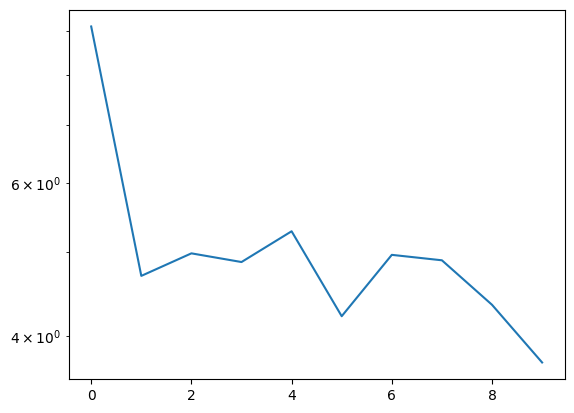

In [35]:
# indices_surface = torch.randint(0, pts_surface.size(0), (1000,)).detach()
# pts_surface_batch = pts_surface[indices_surface]

# Use Laplacian instead of mean curvature?

batch_size_data = 2000
batch_size_eikonal = 1000
model = model.double()
params = model.params
loss_over_iters = {}
# Gauss-Newton:
optimizer = GaussNewtonWoodburyBig(model, lr=1e-1, config=config)
# Adam:
# optim = torch.optim.Adam(model.parameters(), lr=1e-3)
for i in (pbar:=trange(10)):
    optimizer.zero_grad()
    
    with torch.no_grad():

        indices_data = torch.randint(0, x_train.size(0), (batch_size_data,)).detach()
        indices_eikonal = torch.randint(0, x_train.size(0), (batch_size_eikonal,)).detach()
        x_batch = x_train[indices_data]
        vals_batch = vals_data[indices_data]
        data_batch = {"pts_data": x_batch, "vals_data": vals_batch}
        config["data"] = data_batch
        config["pts_eikonal"] = x_train[indices_eikonal]
        indices_surface = torch.randint(0, pts_surface.size(0), (2000,)).detach()
        pts_surface_batch = pts_surface[indices_surface]
        pts_surface = sample_model_surface_binsearch(model, pts_surface_batch, bound_limit=2)
        pts_surface_batch = sample_model_surface_newton(model, pts_surface_batch) 
        config["pts_surface"] = pts_surface_batch
        optimizer.config = config
        
        loss_data  = 0.5*model.r_data(params, x_batch, vals_batch).square().mean()
        loss_eikonal  = 0.5*model.r_eikonal(params, x_batch).squeeze(1).square().mean()
        loss_laplacian = 0.5*model.r_laplacian(params, pts_surface).squeeze(1).square().mean()
        loss = loss_weights["data"] * loss_data + loss_weights["eikonal"] * loss_eikonal + loss_weights["laplacian"] * loss_laplacian
        loss_over_iters[i] = loss.item()
        pbar.set_description(f"Data: {loss_data.item():.2e} "
                            f"Eikonal: {loss_eikonal.item():.2e} "
                            f"Laplacian: {loss_laplacian.item():.2e} ")
    optimizer.step()

plt.plot(loss_over_iters.keys(), loss_over_iters.values())
plt.semilogy()
plt.show()

In [36]:
verts, faces = get_mesh(
    model.float(), N=128, device=device,
    bbox_min=torch.tensor([-1.75, -1.6, -2.6], dtype=torch.float64),
    bbox_max=torch.tensor([2.4, 2.3, 1.7], dtype=torch.float64),
    chunks=2
)

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=0xbbbbbb, side='double', flat_shading=False)
# fig += k3d.points(x_train.cpu().detach(), color=0x00ff00, point_size=0.005)
fig += k3d.points(pts_surface_batch.cpu().detach(), point_size=0.05)
fig.display()

Output()

In [8]:
# Gauss-Newton weights:
pts_surface = x_train[-pts.shape[0]:]
loss_weights = {"mean_curvature": 1.0}

config = {
    "pts_surface": pts_surface,
    "loss_weights": loss_weights,
    "regularization": 1e-6,
}

  0%|          | 0/100 [00:00<?, ?it/s]

/cluster/software/stacks/2024-05/python-cuda/3.11.6/lib/python3.11/site-packages/torch/functional.py:512: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3587.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
N

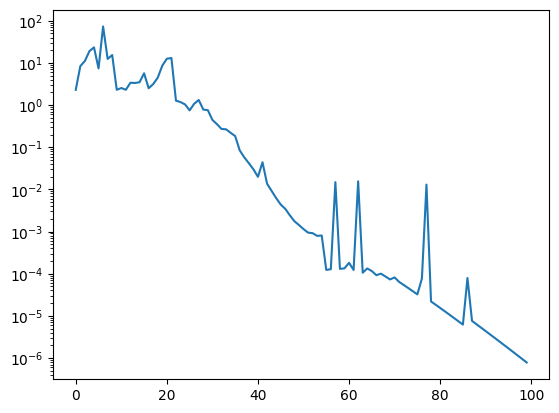

In [9]:
indices_surface = torch.randint(0, pts_surface.size(0), (1000,)).detach()
pts_surface_batch = pts_surface[indices_surface]

model = model.double()
params = model.params
loss_over_iters = {}
# Gauss-Newton:
optimizer = GaussNewtonWoodburyBig(model, lr=1e-1, config=config)
# Adam:
# optim = torch.optim.Adam(model.parameters(), lr=1e-3)
for i in (pbar:=trange(30)):
    optimizer.zero_grad()
    
    with torch.no_grad():
    
        pts_surface = sample_model_surface_binsearch(model, pts_surface_batch, bound_limit=2)
        pts_surface = sample_model_surface_newton(model, pts_surface) 
        config["pts_surface"] = pts_surface
        optimizer.config = config
        
        loss_mean_curvature = 0.5*model.r_mean_curvature(params, pts_surface).squeeze(1).square().mean()
        loss = loss_weights["mean_curvature"] * loss_mean_curvature
        loss_over_iters[i] = loss.item()
        pbar.set_description(f"Mean Curvature: {loss_mean_curvature.item():.2e} ")
    optimizer.step()

plt.plot(loss_over_iters.keys(), loss_over_iters.values())
plt.semilogy()
plt.show()

  0%|          | 0/100 [00:00<?, ?it/s]

/cluster/software/stacks/2024-05/python-cuda/3.11.6/lib/python3.11/site-packages/torch/functional.py:512: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3587.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


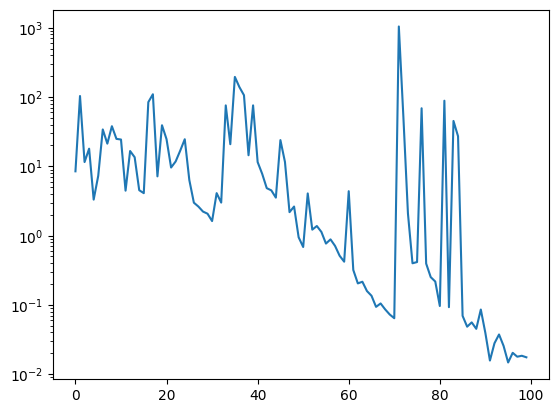

In [13]:
indices_surface = torch.randint(0, pts_surface.size(0), (1000,)).detach()
pts_surface_batch = pts_surface[indices_surface]

model = model.double()
params = model.params
loss_over_iters = {}
# Gauss-Newton:
optimizer = GaussNewtonWoodburyBig(model, lr=1e-1, config=config)
# Adam:
# optim = torch.optim.Adam(model.parameters(), lr=1e-3)
for i in (pbar:=trange(100)):
    optimizer.zero_grad()
    
    with torch.no_grad():
    
        pts_surface = sample_model_surface_binsearch(model, pts_surface_batch, bound_limit=2)
        pts_surface = sample_model_surface_newton(model, pts_surface) 
        config["pts_surface"] = pts_surface
        optimizer.config = config
        
        loss_surface_strain = (0.5*model.r_principle_curvature_1(params, pts_surface).squeeze(1).square().mean() 
                            + 0.5*model.r_principle_curvature_2(params, pts_surface).squeeze(1).square().mean()
        )   
        loss = loss_weights["surface_strain"] * loss_surface_strain
        loss_over_iters[i] = loss.item()
        pbar.set_description(f"Surface Strain: {loss_surface_strain.item():.2e} "
                            )
    optimizer.step()

plt.plot(loss_over_iters.keys(), loss_over_iters.values())
plt.semilogy()
plt.show()

In [10]:
verts, faces = get_mesh(
    model.float(), N=128, device=device,
    bbox_min=torch.tensor([-1.75, -1.6, -2.6], dtype=torch.float64),
    bbox_max=torch.tensor([2.4, 2.3, 1.7], dtype=torch.float64),
    chunks=2
)

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=0xbbbbbb, side='double', flat_shading=False)
# fig += k3d.points(x_train.cpu().detach(), color=0x00ff00, point_size=0.005)
# fig += k3d.points(pts_surface_true.cpu().detach(), point_size=0.05)
fig.display()

Output()